In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

In [10]:
data = load_diabetes()
X = pd.DataFrame(data.data)
y = pd.DataFrame(data.target)
df = X.copy()
df['target'] = y.copy()

In [11]:
def plot_confusion_matrix_simple(cm, labels=("Negative", "Positive"), title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


ValueError: Could not interpret value `age` for `x`. An entry with this name does not appear in `data`.

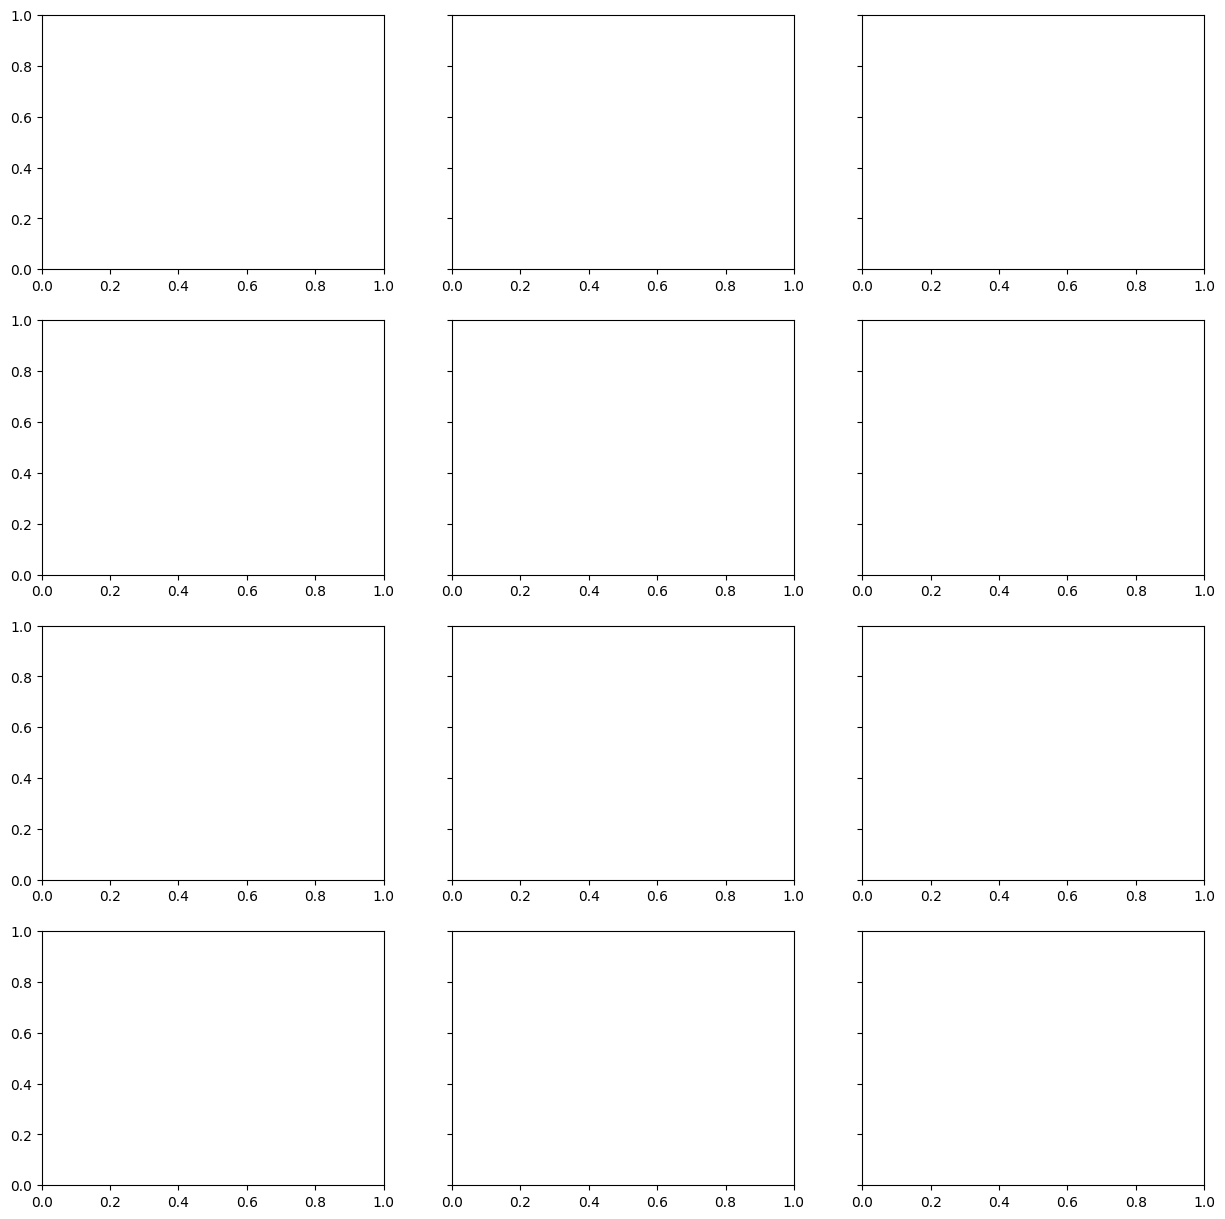

In [12]:
feature_names = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]

n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, f in zip(axes, feature_names):
    sns.scatterplot(data=df, x=f, y="target", ax=ax, alpha=0.5, s=22)
    sns.regplot(data=df, x=f, y="target", ax=ax, scatter=False, color="red", line_kws={"lw": 1.8})
    ax.set_title(f"{f} vs target")

for ax in axes[len(feature_names):]:
    ax.set_visible(False)

fig.suptitle("Relação das features com o target (Regressão)", y=1.02)
plt.tight_layout()
plt.show()